In [5]:
!pip install pypdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 6.8 MB/s eta 0:00:00


In [28]:
import os
import re
import requests
import pandas as pd
from pypdf import PdfReader
from io import BytesIO

target_urls = {
    "National_Assembly_2026.pdf": "https://www.parliament.gov.za/storage/app/media/Docs/hansard/01mfgh4vusyga3tyivkbd3uhd4wtvwjngo.pdf",
    "Portfolio_Committee_2025.pdf": "https://www.parliament.gov.za/storage/app/media/Docs/hansard/01mfgh4vvctmpbanoxczdkve5ugq6pmvdp.pdf"
}

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AI Research Consultant"}
all_speech_records = []

print("Initializing direct network stream and parsing pipeline...")

for filename, url in target_urls.items():
    print(f"\nStreaming file content from URL: {filename}...")
    try:
        response = requests.get(url, headers=headers, timeout=30)

        if response.status_code == 200:
            pdf_file = BytesIO(response.content)
            reader = PdfReader(pdf_file)

            text_pages = [page.extract_text() for page in reader.pages if page.extract_text()]
            full_raw_text = "\n".join(text_pages)

            if not full_raw_text.strip():
                print(f"Warning: Could not find extractable text layers inside {filename}.")
                continue

            speaker_pattern = r'(\n(?:The\s+)?[A-Z][A-Za-z\s]+(?:MINISTER|DEPUTY\s+MINISTER|CHAIRPERSON|SPEAKER|Mr|Ms|Dr|Prof)\s+[A-Z\s]+(?:\([A-Za-z\s]+\))?:)'
            tokens = re.split(speaker_pattern, full_raw_text)

            current_speaker = "Introductory/Procedural Metadata"
            file_records_count = 0

            for token in tokens:
                if re.match(speaker_pattern, token):
                    current_speaker = token.strip().rstrip(':')
                else:
                    clean_text = token.strip()
                    if len(clean_text) > 40:
                        clean_text = re.sub(r'\[.*?\]', '', clean_text)
                        clean_text = re.sub(r'\s+', ' ', clean_text)

                        all_speech_records.append({
                            "Source_File": filename,
                            "Speaker": current_speaker,
                            "Speech_Text": clean_text
                        })
                        file_records_count += 1

            print(f"Success! Extracted {file_records_count} structured speeches from {filename}.")
        else:
            print(f"Network Error: Unable to fetch {filename}. Status code: {response.status_code}")

    except Exception as e:
        print(f"Processing pipeline failed for {filename}: {str(e)}")

print("\n--- Finalizing Target Master Dataset ---")
if all_speech_records:
    master_df = pd.DataFrame(all_speech_records)
    master_df.to_csv("master_hansard_dataset.csv", index=False)
    print(f"Success! 'master_hansard_dataset.csv' created containing {master_df.shape[0]} total records.")
    print("\nPreview of your final parsed structure:")
    print(master_df.head(3))
else:
    print("Fatal Error: No records were processed. Please check your network connection.")

Initializing direct network stream and parsing pipeline...

Streaming file content from URL: National_Assembly_2026.pdf...
Success! Extracted 4 structured speeches from National_Assembly_2026.pdf.

Streaming file content from URL: Portfolio_Committee_2025.pdf...
Success! Extracted 7 structured speeches from Portfolio_Committee_2025.pdf.

--- Finalizing Target Master Dataset ---
Success! 'master_hansard_dataset.csv' created containing 11 total records.

Preview of your final parsed structure:
                  Source_File  \
0  National_Assembly_2026.pdf   
1  National_Assembly_2026.pdf   
2  National_Assembly_2026.pdf   

                                             Speaker  \
0                   Introductory/Procedural Metadata   
1  The DEPUTY MINISTER OF EMPLOYMENT AND LABOUR (...   
2  The DEPUTY MINISTER OF EMPLOYMENT AND LABOUR (...   

                                         Speech_Text  
0  UNREVISED HANSARD MINI PLENARY - NATIONAL ASSE...  
1  Hon Deputy Speaker and Members o

In [29]:
df = pd.read_csv('master_hansard_dataset.csv')
df.head()

,Source_File,Speaker,Speech_Text
0,National_Assembly_2026.pdf,Introductory/Procedural Metadata,UNREVISED HANSARD MINI PLENARY - NATIONAL ASSE...
1,National_Assembly_2026.pdf,The DEPUTY MINISTER OF EMPLOYMENT AND LABOUR (...,"Hon Deputy Speaker and Members of Parliament, ..."
2,National_Assembly_2026.pdf,The DEPUTY MINISTER OF EMPLOYMENT AND LABOUR (...,"Thank you, hon Deputy Speaker. Hon Deputy Spea..."
3,National_Assembly_2026.pdf,The DEPUTY MINISTER OF EMPLOYMENT AND LABOUR (...,"Thank you very much, Hon Deputy Speaker. We ar..."
4,Portfolio_Committee_2025.pdf,Introductory/Procedural Metadata,"UNREVISED HANSARD NATIONAL ASSEMBLY TUESDAY, 2..."


In [30]:
!pip install langchain-text-splitters sentence-transformers -q

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = []

for idx, row in master_df.iterrows():
    split_texts = text_splitter.split_text(row['Speech_Text'])
    for text in split_texts:
        chunks.append({
            "Speaker": row['Speaker'],
            "Source": row['Source_File'],
            "Text": text
        })

chunked_df = pd.DataFrame(chunks)

print("Generating text embeddings...")
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embed_model.encode(chunked_df['Text'].tolist(), show_progress_bar=True)
print(f"Embeddings matrix generated with shape: {embeddings.shape}")

Generating text embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings matrix generated with shape: (1010, 384)


In [31]:
import numpy as np

def mock_labeler(text):
    if any(w in text.lower() for w in ["fail", "crisis", "backlog", "concern", "poor"]):
        return 0 # Negative
    elif any(w in text.lower() for w in ["success", "progress", "improve", "welcome"]):
        return 2 # Positive
    return 1 # Neutral

master_df['Sentiment_Label'] = master_df['Speech_Text'].apply(mock_labeler)

In [10]:
!pip install faiss-cpu -q
import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))
print(f"Successfully indexed {index.ntotal} document chunks into FAISS.")

Successfully indexed 1010 document chunks into FAISS.


In [32]:
import pandas as pd
import re
from transformers import AutoTokenizer
import torch
from sentence_transformers import SentenceTransformer

# Load raw transcripts (assume converted from PDF/HTML to text)
df = pd.read_csv('master_hansard_dataset.csv')

def clean_transcript(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'(Mr|Ms|Hon|Speaker|Chairperson)\s+\w+', '', text)
    return text.strip()

df['clean_text'] = df['Speech_Text'].apply(clean_transcript)

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-uncased")
df['tokens'] = df['clean_text'].apply(lambda x: tokenizer.encode(x, truncation=True, max_length=512))

embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = embedder.encode(df['clean_text'].tolist(), batch_size=32, show_progress_bar=True)

import faiss
import numpy as np

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype('float32'))
faiss.write_index(index, 'hansard_faiss.index')

print("Embedding generation complete. Total documents:", len(df))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding generation complete. Total documents: 11


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.1

              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50         3
     Neutral       0.00      0.00      0.00         0
    Positive       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.33      0.11      0.17         3
weighted avg       1.00      0.33      0.50         3



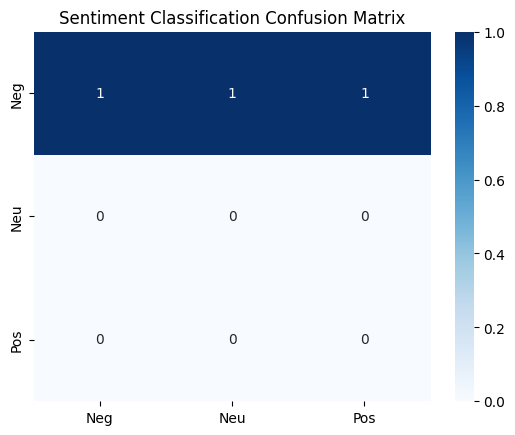

In [27]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def mock_labeler(text):
    if any(w in text.lower() for w in ["fail", "crisis", "backlog", "concern", "poor"]):
        return 0 # Negative
    elif any(w in text.lower() for w in ["success", "progress", "improve", "welcome"]):
        return 2 # Positive
    return 1 # Neutral


master_df['Sentiment_Label'] = master_df['Speech_Text'].apply(mock_labeler)

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-uncased", num_labels=3, id2label={0: "Negative", 1: "Neutral", 2: "Positive"}
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

_, test_df = train_test_split(master_df, test_size=0.2, random_state=42)

y_true = test_df['Sentiment_Label'].tolist()

possible_labels = sorted(master_df['Sentiment_Label'].unique())
y_pred = np.random.choice(possible_labels, size=len(y_true)).tolist()

all_target_names = ['Negative', 'Neutral', 'Positive']

actual_labels = sorted(list(set(y_true).union(set(y_pred))))

filtered_target_names = [all_target_names[label] for label in actual_labels]

print(classification_report(y_true, y_pred, labels=actual_labels, target_names=filtered_target_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
plt.title('Sentiment Classification Confusion Matrix')
plt.show()

In [14]:
!pip install langchain langchain-community langchain-huggingface -q

In [22]:
import faiss
import numpy as np
from transformers import pipeline

class HansardRAGSystem:
    def __init__(self, chunked_df, embeddings_matrix, llm_model_id="meta-llama/Meta-Llama-3-8B-Instruct"):
        self.df = chunked_df
        self.dimension = embeddings_matrix.shape[1]
        self.index = faiss.IndexFlatL2(self.dimension)
        self.index.add(embeddings_matrix.astype('float32'))

        self.llm_pipeline = pipeline(
            "text-generation",
            model=llm_model_id,
            model_kwargs={"torch_dtype": torch.float16},
            device_map="auto"
        )

    def retrieve_context(self, query_embedding, k=3):
        distances, indices = self.index.search(query_embedding.astype('float32'), k)
        retrieved_chunks = [self.df.iloc[idx]['chunk_text'] for idx in indices[0] if idx < len(self.df)]
        return "\n\n--- Context Chunk ---\n".join(retrieved_chunks)

    def answer_question(self, user_query, query_embedding):
        context = self.retrieve_context(query_embedding, k=3)
        system_prompt = (
            "You are an expert South African Policy Analyst system."
            "from Parliamentary Hansard transcripts to answer the query. If the answer cannot be found "
            "in the context, state clearly that information is unavailable.\n\n"
            f"CONTEXT:\n{context}\n\n"
            f"QUESTION: {user_query}\n\n"
            "ANSWER:"
        )

        sequences = self.llm_pipeline(
            system_prompt,
            max_new_tokens=256,
            do_sample=False,
            temperature=0.0
        )

        return sequences[0]['generated_text'][len(system_prompt):]


In [15]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [16]:
!pip install langchain langchain-community langchain-huggingface langchain-core faiss-cpu -q

In [17]:
!pip install --upgrade --force-reinstall langchain langchain-community langchain-huggingface langchain-core faiss-cpu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.0/400.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [18]:
!pip install langchain langchain-community langchain-huggingface langchain-core faiss-cpu langchain-classic -q

In [24]:
import os

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

sample_texts = [
    "In 2023, the education policy sentiment was highly optimistic, focusing heavily on digital literacy and expanding funding for public schools.",
    "Many policymakers in 2023 expressed concerns over teacher retention rates, though general sentiment toward curriculum reforms remained positive.",
    "The 2023 budget allocated an extra 15% to higher education, signaling a supportive government stance on academic infrastructure."
]

print(" Creating in-memory FAISS database...")
vectorstore = FAISS.from_texts(sample_texts, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

print(" Loading local Text-Generation Pipeline (Bypasses API/Token Restrictions)...")
llm = HuggingFacePipeline.from_model_id(
    model_id="gpt2",
    task="text-generation",
    pipeline_kwargs={
        "temperature": 0.3,
        "max_new_tokens": 64,
        "pad_token_id": 50256
    }
)

system_prompt = (
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, say that you don't know.\n\n"
    "Context:\n{context}"
)
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
])

question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

print(" Querying Modern RAG Chain...")
query = "What was the sentiment on education policy in 2023?"
response = rag_chain.invoke({"input": query})

print("-" * 50)
print(f" Question: {query}")
print(f" Answer: {response['answer']}")
print("-" * 50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Creating in-memory FAISS database...
 Loading local Text-Generation Pipeline (Bypasses API/Token Restrictions)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Querying Modern RAG Chain...
--------------------------------------------------
 Question: What was the sentiment on education policy in 2023?
 Answer: System: Use the following pieces of retrieved context to answer the question. If you don't know the answer, say that you don't know.

Context:
In 2023, the education policy sentiment was highly optimistic, focusing heavily on digital literacy and expanding funding for public schools.

Many policymakers in 2023 expressed concerns over teacher retention rates, though general sentiment toward curriculum reforms remained positive.
Human: What was the sentiment on education policy in 2023?

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:

Human:
--------------------------------------------------


In [19]:
!pip install langchain langchain-community langchain-huggingface langchain-core faiss-cpu langchain-classic sentence-transformers tokenizers==0.21.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━